# EgoPressure — Quickstart

Load, visualize, and train on the [EgoPressure dataset](https://huggingface.co/datasets/eth-siplab/EgoPressure)
(CVPR 2025): 21 participants, 8 synchronized RGB-D views, MANO hand meshes, and
fine-grained touch pressure.

```bash
pip install "egopressure[all] @ git+https://github.com/eth-siplab/EgoPressure"
```

Full data reference (fields, units, conventions):
[docs/DATA.md](../docs/DATA.md).

## 1. Download a slice

Everything is sharded by participant / sequence / camera / modality — fetch only what you need. One sequence with all cameras is ~1.5–2.5 GB. The download is **incremental**: files you already have are skipped, so re-running this cell is cheap and also repairs partial downloads.

In [1]:
from egopressure import EgoPressure
from egopressure.hub import download

ROOT = "egopressure_data"
PID, SEQ = "p_001", "p_001_pull-towards_5x_right"

download(participants=[PID], sequences=[SEQ],
         modalities=["rgb", "depth", "pressure", "pose"], out_dir=ROOT)

ep = EgoPressure(ROOT)
seq = ep.sequence(PID, SEQ)
seq

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 27 files:   0%|          | 0/27 [00:00<?, ?it/s]

<ParquetSequence 'p_001_pull-towards_5x_right': 497 frames>

## 2. A frame with every modality

We pick the frame with the strongest touch pressure. Units: RGB undistorted uint8; depth uint16 millimetres (depth-sensor frame); force float32 Sensel counts; MANO vertices in metres (world frame — the touchpad surface is the plane z = 0, with +z pointing down through the pad).

In [2]:
from egopressure.senselpad import counts_to_kpa

fi = max(seq.annotated_frames(), key=lambda f: seq.load_force(f).max())
frame = seq.load_frame(fi, depth=True)

print(f"frame {fi} (peak-pressure frame of this sequence)")
print(f"  ego RGB   {frame.rgb['d'].shape}")
print(f"  depth     {frame.depth['d'].shape} {frame.depth['d'].dtype}, "
      f"{frame.depth['d'].max()} mm max")
print(f"  force     {frame.force.shape}, peak "
      f"{counts_to_kpa(frame.force).max():.1f} kPa")
v = frame.annotation.vertices
print(f"  vertices  {v.shape}, z in [{v[:, 2].min():+.3f}, "
      f"{v[:, 2].max():+.3f}] m (negative = above the pad)")

frame 283 (peak-pressure frame of this sequence)
  ego RGB   (1080, 1920, 3)
  depth     (512, 512) uint16, 3239 mm max
  force     (105, 185), peak 102.8 kPa
  vertices  (778, 3), z in [-0.053, +0.004] m (negative = above the pad)


## 3. Visualize

MANO mesh and skeleton projected through the camera calibration, the measured pressure as a white glow, plus the raw force grid and the hand-UV pressure map.

> The shaded hand surface and the UV wireframe need the user-provided MANO files ([../mano_models/README.md](../mano_models/README.md)); without them the hand renders as vertex dots.

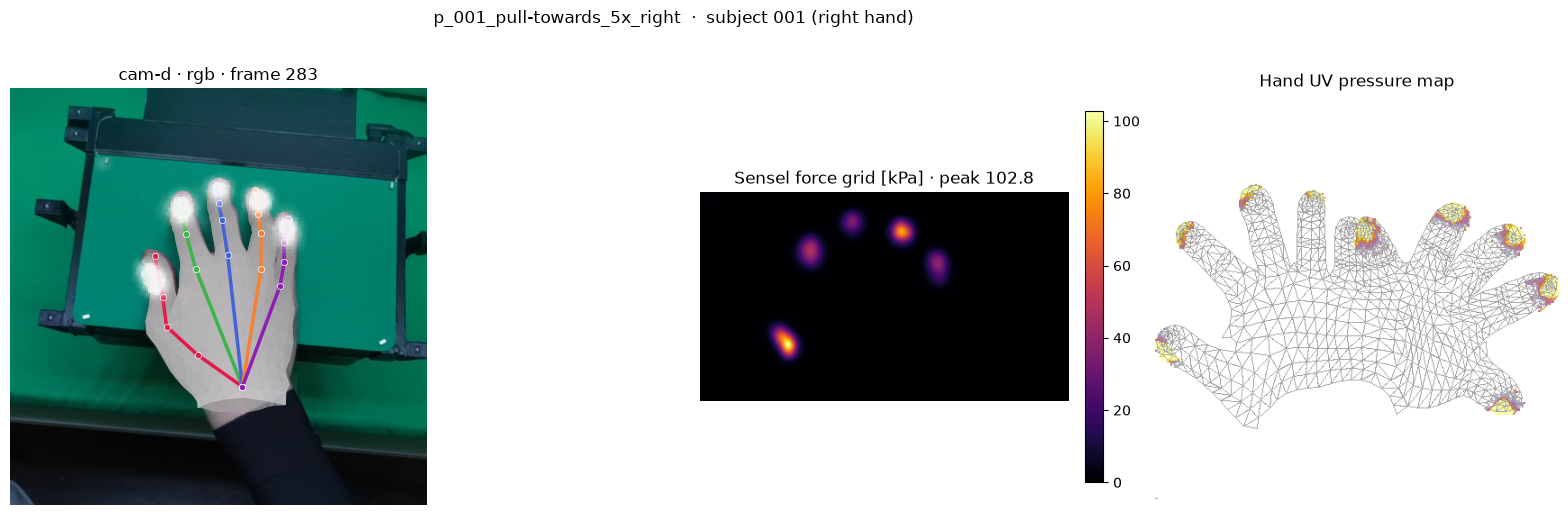

In [3]:
fig = frame.show(camera="d", overlays=["mesh", "skeleton", "pressure"])

## 4. Geometry in a few calls

Static cameras carry a fixed extrinsic; the egocentric camera has a per-frame pose in the annotation. Millimetre/metre conventions are handled internally. `warp_force_to_image` projects the raw sensor grid into **any** camera view — shown here overlaid on static camera 4.

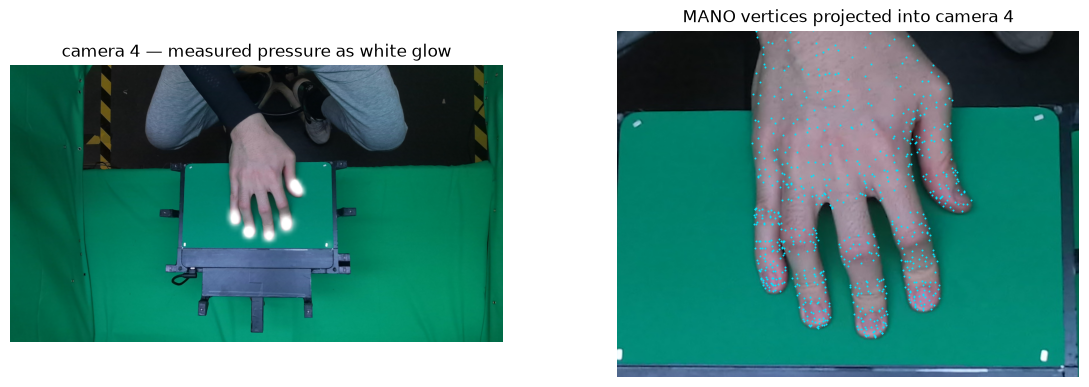

In [4]:
import matplotlib.pyplot as plt
import numpy as np

from egopressure.senselpad import SENSEL_MAX_VIS_KPA, warp_force_to_image

ann = frame.annotation
cal4 = seq.calibration("4")                     # static camera 4
uv4 = cal4.project_world(ann.vertices)          # mesh -> pixels

kpa_img = warp_force_to_image(frame.force, cal4, image_shape=(1440, 2560))

rgb4 = seq.load_rgb(fi, "4")
alpha = np.sqrt(np.clip(kpa_img / SENSEL_MAX_VIS_KPA, 0, 1))[..., None]
composite = ((1 - alpha) * rgb4 + alpha * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].imshow(composite)
axes[0].set_title("camera 4 — measured pressure as white glow")
axes[1].imshow(seq.load_rgb(fi, "4"))
axes[1].scatter(uv4[:, 0], uv4[:, 1], s=2, c="#00e5ff", linewidths=0)
cx, cy = np.nanmean(uv4, axis=0)
axes[1].set_xlim(cx - 400, cx + 400)
axes[1].set_ylim(cy + 300, cy - 300)
axes[1].set_title("MANO vertices projected into camera 4")
for ax in axes:
    ax.axis("off")

### Depth: register to color, unproject to 3D

Raw depth maps come from the **depth sensor** (own lens, not pixel-aligned with RGB). `register_depth_to_color` reprojects them into the color camera's view; `world_points_from_depth` goes straight to a world-frame point cloud in metres.

world cloud: 25,790 points; points over the pad have median z = +7.9 mm — i.e. on the pad surface (z = 0), as expected


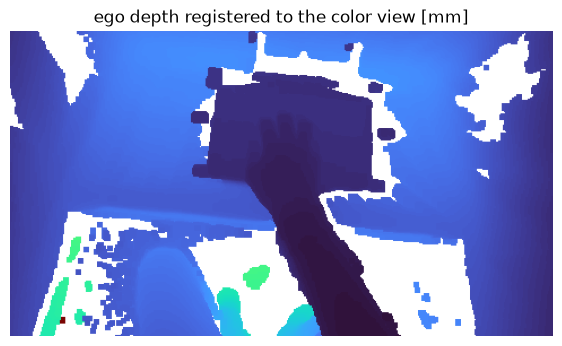

In [5]:
from egopressure.registration import (register_depth_to_color,
                                      world_points_from_depth)

reg = register_depth_to_color(seq, fi, "d", scale=4)    # ego view, mm
pts = world_points_from_depth(seq, fi, "d", stride=2)   # world cloud, metres

fig, ax = plt.subplots(figsize=(7, 4))
ax.imshow(np.where(reg > 0, reg, np.nan), cmap="turbo")
ax.set_title("ego depth registered to the color view [mm]")
ax.axis("off")

from egopressure.senselpad import SENSEL_H, SENSEL_W

pad = pts[(np.abs(pts[:, 0]) < SENSEL_W / 2) & (np.abs(pts[:, 1]) < SENSEL_H / 2)]
print(f"world cloud: {len(pts):,} points; points over the pad have median "
      f"z = {np.median(pad[:, 2]) * 1000:+.1f} mm — i.e. on the pad surface "
      "(z = 0), as expected")

## 5. Training-ready datasets

`EgoPressureFrames` is a `torch.utils.data.Dataset` over frames; `EgoPressureClips` samples fixed-length temporal windows that never cross a sequence boundary. (Both need `torch`, included in the `[all]` extra and the conda `environment.yml`.)

In [6]:
from torch.utils.data import DataLoader

from egopressure.torch_dataset import (EgoPressureClips, EgoPressureFrames,
                                       collate_frames)

data = EgoPressureFrames(ROOT, annotated_only=True, cameras=["d"])
loader = DataLoader(data, batch_size=8, collate_fn=collate_frames)
batch = next(iter(loader))

clips = EgoPressureClips(ROOT, window=16, stride=2, annotated_only=True,
                         cameras=["d"])
print(f"{len(data)} annotated frames | first batch: {len(batch)} frames | "
      f"{len(clips)} sixteen-frame clips (stride 2)")

437 annotated frames | first batch: 8 frames | 13 sixteen-frame clips (stride 2)


## 6. All cameras at a glance

`seq.show(...)` renders any single view; the grid below montages every camera for one frame. In a live Jupyter session, `seq.viewer().interact()` adds a frame slider with camera and overlay controls. Full sequence videos render from the CLI:

```bash
egopressure video p_001 p_001_pull-towards_5x_right --out seq.mp4
```

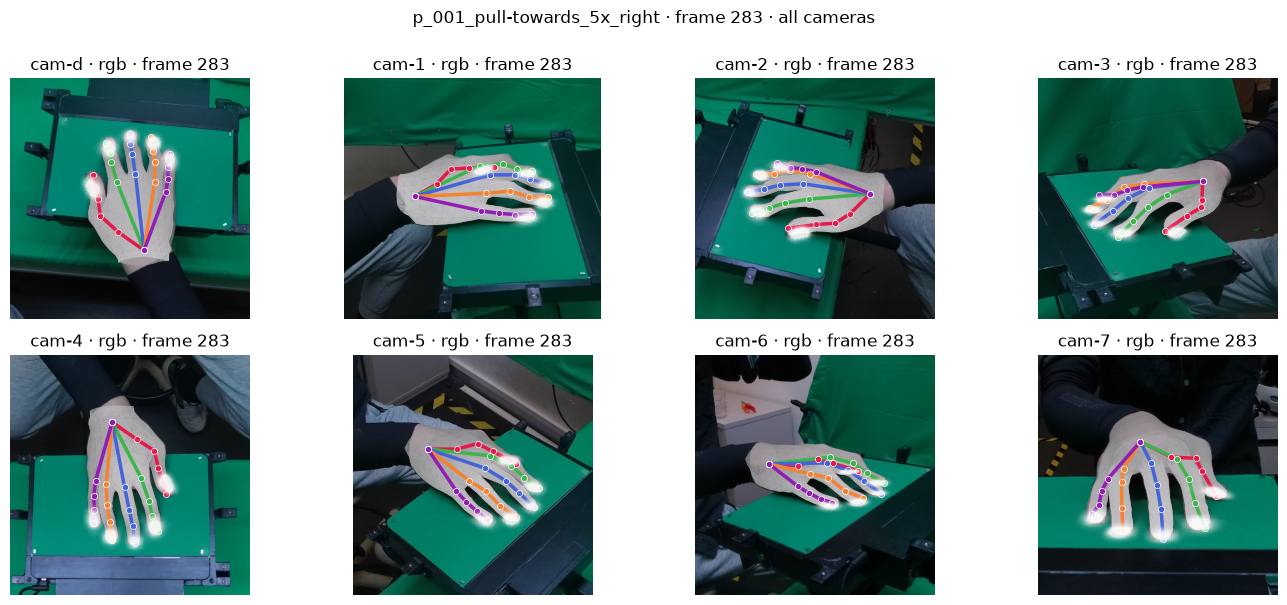

In [7]:
fig = seq.viewer().grid(fi)                      # all cameras, RGB

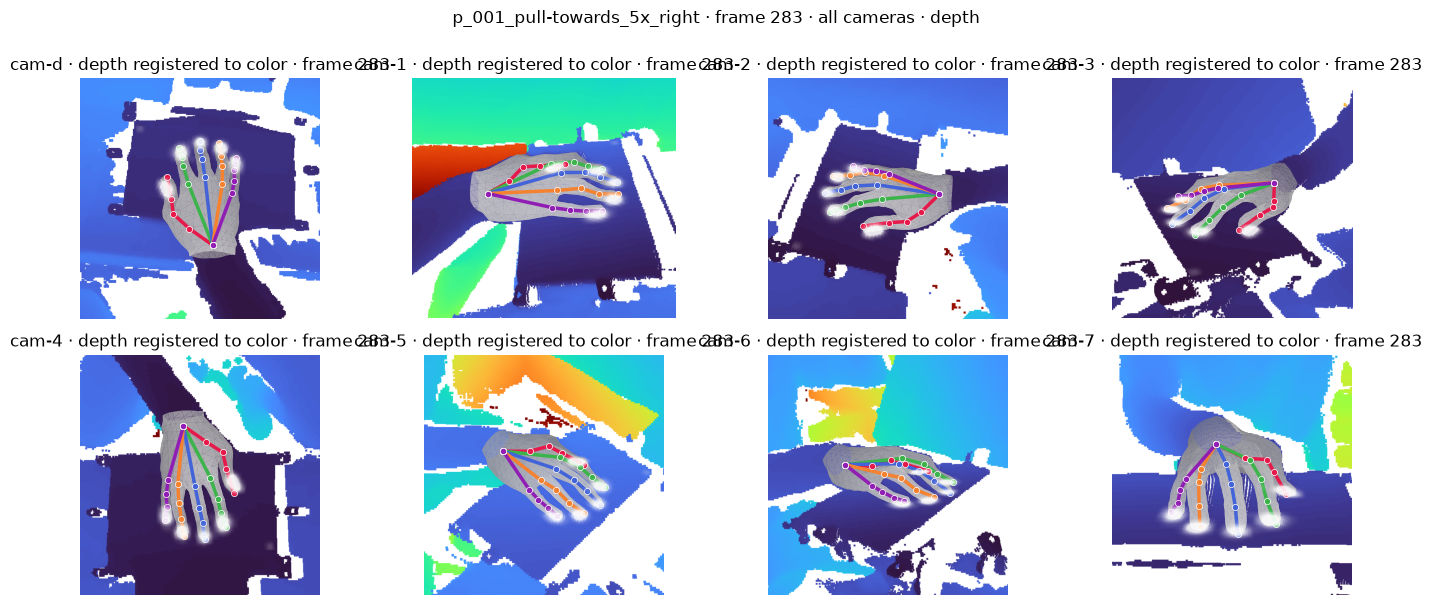

In [8]:
fig = seq.viewer().grid(fi, modality="depth")    # registered depth, same overlays

## 7. Interactive scrubber

In a live Jupyter session, uncomment and run the cell below: a frame slider with camera, modality (RGB / registered depth), and overlay controls.

In [9]:
# seq.viewer().interact()